In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import mgefit as mge
from astropy.io import fits
import sys

In [2]:
sys.path.append('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/scripts')
import mge_ifu_merged as mg_help

# Load data

In [3]:
img_f200 = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/photometry/f200w_ifu_coadd_masked.fits')[0].data
dust_mask = fits.open('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/dust_mask/f200_mask_1.fits')[0].data

nan_mask = np.isnan(img_f200)
if np.any(nan_mask):
    print(f"Found {np.sum(nan_mask)} NaN pixels in the image. Replacing with 0 and adding to dust mask.")
    img_f200[nan_mask] = 0.0
    dust_mask = dust_mask | nan_mask


Found 79853441 NaN pixels in the image. Replacing with 0 and adding to dust mask.


In [4]:
img = np.asarray(img_f200, dtype=float)
dust_mask_is_bad = True
if img.ndim != 2:
    raise ValueError("img_f200 must be a 2D array")

mask = np.asarray(dust_mask)
if mask.shape != img.shape:
    raise ValueError("dust_mask must have the same shape as img_f200")
if mask.dtype != bool:
    mask = mask.astype(bool)

goodmask = (~mask) if dust_mask_is_bad else mask

# Fill masked pixels for find_galaxy stability
img_for_find = img.copy()
fill = np.nanmedian(img[goodmask]) if np.any(goodmask) else np.nanmedian(img)
img_for_find[~goodmask] = fill
if not np.all(np.isfinite(img_for_find)):
    raise ValueError("Image contains NaN/Inf even after filling masked pixels")

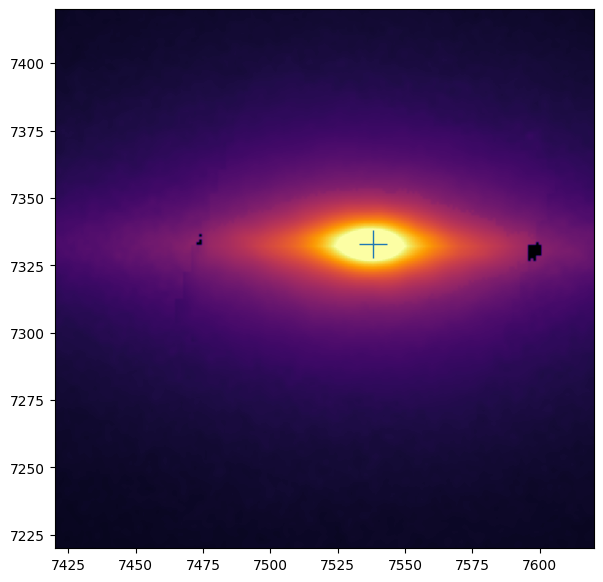

In [11]:
# plot img for find
fig, ax = plt.subplots(figsize=(10, 7))
zm_region = np.array(((7400, 7600), (7200, 7400))) + 20
im = ax.imshow(img_for_find, origin='lower', cmap='inferno',
                vmin=np.percentile(img_for_find, 0.1), vmax=np.percentile(img_for_find, 99.9999),
                # zoom into central region for better visualization
                #extent=(zm_region[0][0], zm_region[0][1], zm_region[1][0], zm_region[1][1])
                )
# mark the inital guess for center
ax.plot([7538], [7333],  marker='+', markersize = 20)
ax.set_xlim(zm_region[0][0], zm_region[0][1])
ax.set_ylim(zm_region[1][0], zm_region[1][1])
plt.show()

 Pixels used: 20509763
 Peak img[j, k]: 7341, 7538
 Mean (j, k): 7361.33 7520.66
 Theta (deg): 0.8
 Astro PA (deg): 89.2
 Eps: 0.633
 Major axis (pix): 5281.4


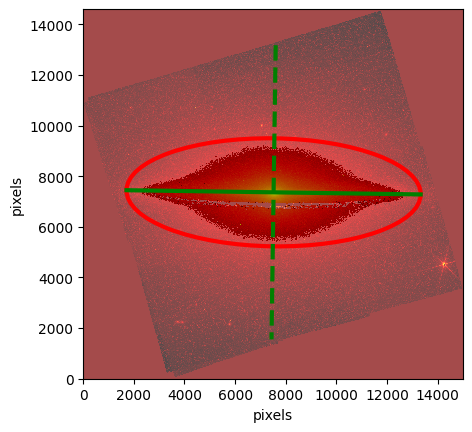

In [13]:
def _do_find():
    return mge.find_galaxy(
        img_for_find,
        fraction=0.1,
        #binning=10,
        plot=True,
        quiet=False
    )

f, new_figs = mg_help._capture_new_figures(_do_find)

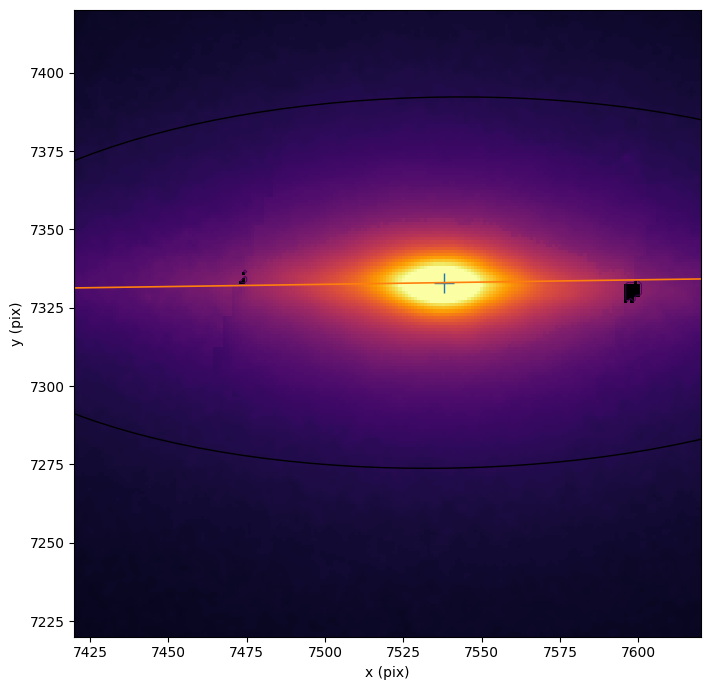

In [37]:

# Custom geometry overlay
xc, yc = 7538, 7333#f.xpeak, f.ymed  # (row, col)
pa = float(f.pa)
eps = float(f.eps)
qbar = 1.0 - eps
pixel_scale=0.031

fig, ax = plt.subplots(figsize=(10, 7))
#ax.imshow(mg_help._stretch_for_display(img, goodmask=goodmask), origin="lower")
ax.imshow(img_for_find, origin="lower", cmap='inferno',
          vmin=np.percentile(img_for_find, 0.1), vmax=np.percentile(img_for_find, 99.9999))
try:
    ax.contour((~goodmask).astype(float), levels=[0.5], linewidths=0.8, alpha=0.8, origin="lower")
except Exception:
    pass
ax.plot([xc], [yc], marker="+", markersize=14)

L_arcsec = 20.0
L_pix = L_arcsec / pixel_scale
pa_rad = np.deg2rad(pa)
dx = L_pix * np.sin(pa_rad)
dy = L_pix * np.cos(pa_rad)
ax.plot([xc - dx, xc + dx], [yc - dy, yc + dy], linewidth=1.2)

for a_arc in [5.0, 15.0, 30.0]:
    a_pix = a_arc / pixel_scale
    b_pix = a_pix * qbar
    e = Ellipse((xc, yc), width=2*a_pix, height=2*b_pix, angle=(90.0 - pa),
                fill=False, linewidth=1.0)
    ax.add_patch(e)

#ax.set_title(f"{prefix}: geometry overlay  (PA={pa:.2f} deg, eps={eps:.3f})")
ax.set_xlabel("x (pix)")
ax.set_ylabel("y (pix)")
ax.set_xlim(zm_region[0][0], zm_region[0][1])
ax.set_ylim(zm_region[1][0], zm_region[1][1])
fig.tight_layout()
#fig.savefig(os.path.join(checkplot_dir, f"{prefix}_01_geometry_overlay.png"), dpi=dpi)
#plt.close(fig)
plt.show()

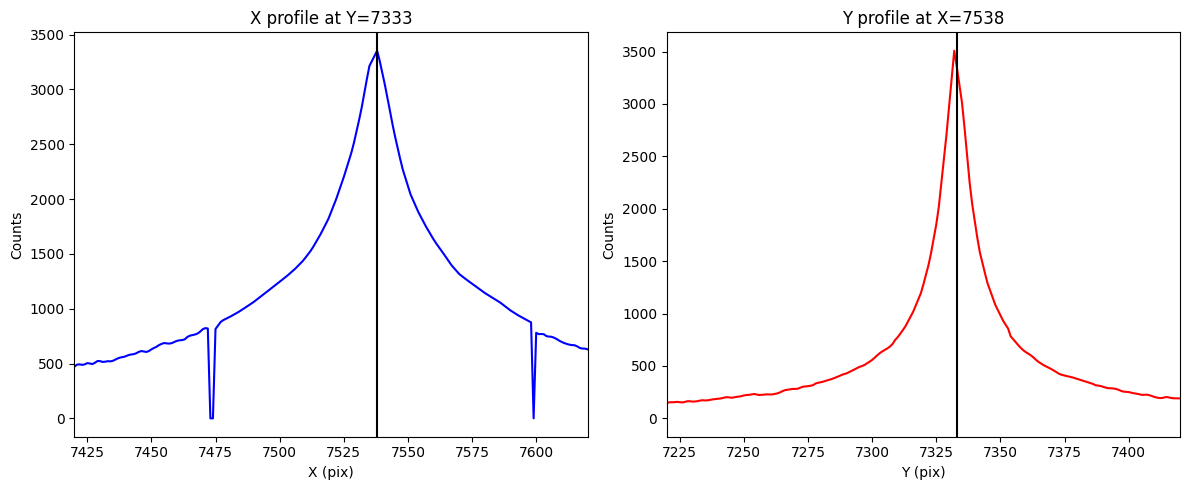

In [17]:
# plot count histogram in the X direction at the Y center and the Y direction at the X center
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
y_center = int(round(yc))
x_center = int(round(xc))
ax[0].plot(img[y_center, :], color='blue')
ax[0].set_title(f"X profile at Y={y_center}")
ax[0].set_xlabel("X (pix)")
ax[0].set_ylabel("Counts")
ax[1].plot(img[:, x_center], color='red')
ax[1].set_title(f"Y profile at X={x_center}")
ax[1].set_xlabel("Y (pix)")
ax[1].set_ylabel("Counts")

# add vertical lines at the center and at the edges of the zoomed region

ax[0].axvline(x=x_center, color='black', linestyle='-')

ax[1].axvline(x=y_center, color='black', linestyle='-')
plt.tight_layout()
#fig.savefig(os.path.join(checkplot_dir, f"{prefix}_02_profiles.png"), dpi=dpi)
#plt.close(fig)
ax[0].set_xlim(zm_region[0][0], zm_region[0][1])
ax[1].set_xlim(zm_region[1][0], zm_region[1][1])
plt.show()

# Make my own fitting routine

In [18]:
import numpy as np
from scipy.optimize import least_squares

# ----------------------------
# Utilities
# ----------------------------
def bin2d_mean(a, factor: int):
    """Fast block-mean binning. Crops edges to be divisible by factor."""
    a = np.asarray(a)
    ny, nx = a.shape
    ny2 = (ny // factor) * factor
    nx2 = (nx // factor) * factor
    a2 = a[:ny2, :nx2]
    return a2.reshape(ny2 // factor, factor, nx2 // factor, factor).mean(axis=(1, 3))

def cutout2d(img, x0, y0, half_size):
    """
    Return a view (slice) when possible.
    Output:
      cut, (x1, y1) where (x1,y1) is cutout origin in full-image pixels.
    """
    ny, nx = img.shape
    x0 = int(round(x0)); y0 = int(round(y0))
    x1 = max(0, x0 - half_size)
    x2 = min(nx, x0 + half_size + 1)
    y1 = max(0, y0 - half_size)
    y2 = min(ny, y0 + half_size + 1)
    return img[y1:y2, x1:x2], (x1, y1)

def robust_sky_from_border(cut, border=20):
    """Median of a border frame (robust-ish background estimate)."""
    ny, nx = cut.shape
    b = border
    if ny <= 2*b or nx <= 2*b:
        return np.nanmedian(cut)
    top = cut[:b, :]
    bot = cut[-b:, :]
    left = cut[:, :b]
    right = cut[:, -b:]
    return np.nanmedian(np.concatenate([top.ravel(), bot.ravel(), left.ravel(), right.ravel()]))

def moments_ellipse(cut, sky=None):
    """
    Quick weighted-moment estimate of centroid, sigmas, and PA.
    Returns (cx, cy, sx, sy, theta) in cutout pixel coordinates.
    """
    if sky is None:
        sky = robust_sky_from_border(cut)

    img = np.asarray(cut, dtype=np.float64)
    w = img - sky
    w[~np.isfinite(w)] = 0.0
    w[w < 0] = 0.0

    ys, xs = np.indices(img.shape)
    sw = w.sum()
    if sw <= 0:
        # fallback: center of cutout
        cy = 0.5 * (img.shape[0] - 1)
        cx = 0.5 * (img.shape[1] - 1)
        return cx, cy, 5.0, 5.0, 0.0

    cx = (w * xs).sum() / sw
    cy = (w * ys).sum() / sw
    dx = xs - cx
    dy = ys - cy

    Ixx = (w * dx * dx).sum() / sw
    Iyy = (w * dy * dy).sum() / sw
    Ixy = (w * dx * dy).sum() / sw

    # eigenvectors of covariance -> principal axes
    tr = Ixx + Iyy
    det = Ixx * Iyy - Ixy * Ixy
    lam1 = 0.5 * (tr + np.sqrt(max(tr*tr - 4*det, 0.0)))
    lam2 = 0.5 * (tr - np.sqrt(max(tr*tr - 4*det, 0.0)))
    sx = np.sqrt(max(lam1, 1e-6))
    sy = np.sqrt(max(lam2, 1e-6))

    # angle of major axis: 0.5*atan2(2Ixy, Ixx-Iyy)
    theta = 0.5 * np.arctan2(2*Ixy, (Ixx - Iyy))
    # ensure sx >= sy
    if sy > sx:
        sx, sy = sy, sx
        theta += np.pi/2

    # keep theta in [-pi/2, pi/2)
    theta = (theta + np.pi/2) % np.pi - np.pi/2
    return cx, cy, sx, sy, theta

def bn_approx(n):
    """
    Approximation for the Sérsic b_n constant (good for typical n).
    """
    n = np.asarray(n, dtype=np.float64)
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2) + 131/(1148175*n**3)

def _rot(dx, dy, theta):
    c = np.cos(theta); s = np.sin(theta)
    xp = c*dx + s*dy
    yp = -s*dx + c*dy
    return xp, yp

# ----------------------------
# Bases (linear in amp + sky)
# model = sky + amp * base(...)
# ----------------------------
def gaussian_base(x, y, cx, cy, sx, sy, theta):
    dx = x - cx
    dy = y - cy
    xp, yp = _rot(dx, dy, theta)
    return np.exp(-0.5*((xp/sx)**2 + (yp/sy)**2))

def sersic_base(x, y, cx, cy, re, n, q, theta):
    dx = x - cx
    dy = y - cy
    xp, yp = _rot(dx, dy, theta)
    r2 = xp*xp + (yp/q)**2
    b = float(bn_approx(n))
    # (sqrt(r2)/re)**(1/n)  ==  (r2**(0.5/n)) / (re**(1/n))
    t = (r2**(0.5/n)) / (re**(1.0/n))
    # clip exponent to avoid overflow in extreme cases
    expo = np.clip(-b*(t - 1.0), -700.0, 80.0)
    return np.exp(expo)

def solve_amp_sky(img, base, w=None):
    """
    Weighted least-squares solve for (amp, sky) in img ~ sky + amp*base.
    """
    img = np.asarray(img, dtype=np.float64)
    base = np.asarray(base, dtype=np.float64)

    if w is None:
        S1  = img.size
        Sb  = base.sum()
        Sbb = (base*base).sum()
        Sy  = img.sum()
        Sby = (base*img).sum()
    else:
        w = np.asarray(w, dtype=np.float64)
        S1  = w.sum()
        Sb  = (w*base).sum()
        Sbb = (w*base*base).sum()
        Sy  = (w*img).sum()
        Sby = (w*base*img).sum()

    det = S1*Sbb - Sb*Sb
    if det <= 0:
        sky = np.nanmedian(img)
        amp = np.nanmax(img - sky)
        return amp, sky

    sky = (Sy*Sbb - Sb*Sby) / det
    amp = (S1*Sby - Sb*Sy) / det
    return amp, sky

def chi2_for_center(img, x, y, cx, cy, base_func, shape_params, w=None):
    base = base_func(x, y, cx, cy, *shape_params)
    amp, sky = solve_amp_sky(img, base, w=w)
    model = sky + amp*base
    resid = img - model
    if w is None:
        return float((resid*resid).sum()), amp, sky
    return float((w*resid*resid).sum()), amp, sky

def pattern_search_center(img, x, y, cx0, cy0, base_func, shape_params,
                         w=None, step0=8.0, min_step=0.25, max_iter=200,
                         bounds=None):
    """
    Hill-climbing / pattern search on (cx,cy).
    Checks 8 neighbors at each step; if no improvement, halves step.
    """
    ny, nx = img.shape
    cx = float(cx0); cy = float(cy0)
    step = float(step0)

    def clamp(cx, cy):
        if bounds is None:
            return cx, cy
        (xmin, xmax, ymin, ymax) = bounds
        return (min(max(cx, xmin), xmax), min(max(cy, ymin), ymax))

    cx, cy = clamp(cx, cy)
    best, amp, sky = chi2_for_center(img, x, y, cx, cy, base_func, shape_params, w=w)

    it = 0
    while step >= min_step and it < max_iter:
        it += 1
        candidates = [
            (cx+step, cy), (cx-step, cy), (cx, cy+step), (cx, cy-step),
            (cx+step, cy+step), (cx+step, cy-step), (cx-step, cy+step), (cx-step, cy-step)
        ]
        improved = False
        for tx, ty in candidates:
            tx, ty = clamp(tx, ty)
            val, a, s = chi2_for_center(img, x, y, tx, ty, base_func, shape_params, w=w)
            if val < best:
                best, amp, sky = val, a, s
                cx, cy = tx, ty
                improved = True
        if not improved:
            step *= 0.5

    return cx, cy, best, amp, sky


# Main high-level fitter

def fit_galaxy_2d(image, x_guess, y_guess,
                  model="gaussian",
                  cutout_half_size=1024,
                  bin_factors=(16, 8, 4, 2, 1),
                  step0_pix=32.0,
                  min_step_pix=0.25,
                  refine_nonlinear=True,
                  stride_fullres=2,
                  rmax_fullres=None,
                  disk_intrinsic_thickness_q0=0.0):
    """
    Fit center + ellipse params from a 2D Gaussian or Sérsic model.

    Returns a dict with:
      x_cen, y_cen (full-image pixels),
      pa_rad, q, inclination_deg,
      plus model parameters (amp, sky, etc.)

    Notes:
      - theta (pa_rad) is measured in *image pixel coordinates* with y increasing downward.
      - Inclination uses q and optional q0: cos^2 i = (q^2 - q0^2)/(1-q0^2)
    """
    img = image  # assume already array-like (possibly memmap)
    cut, (x1, y1) = cutout2d(img, x_guess, y_guess, cutout_half_size)
    cut = np.asarray(cut, dtype=np.float32)

    # coordinate grids for FULL-RES cutout (reused later)
    ys_full, xs_full = np.indices(cut.shape)
    xs_full = xs_full.astype(np.float32)
    ys_full = ys_full.astype(np.float32)

    # quick initial shape guess from moments
    sky0 = robust_sky_from_border(cut)
    cx0, cy0, sx0, sy0, th0 = moments_ellipse(cut, sky=sky0)
    q0 = max(min(sy0/sx0, 1.0), 1e-3)

    if model.lower() == "gaussian":
        base_func = gaussian_base
        shape_full = (sx0, sy0, th0)  # sx, sy, theta
    elif model.lower() == "sersic":
        base_func = sersic_base
        # very rough Re guess from moments; n guess = 1 (exp)
        re0 = max(1.0, 1.5*np.sqrt(sx0*sy0))
        n0 = 1.0
        shape_full = (re0, n0, q0, th0)  # re, n, q, theta
    else:
        raise ValueError("model must be 'gaussian' or 'sersic'")

    # multiscale center search (binning)
    cx, cy = cx0, cy0
    amp, sky = None, None

    for bf in bin_factors:
        if bf == 1:
            cut_b = cut.astype(np.float32, copy=False)
            xs_b, ys_b = xs_full, ys_full
            cx_b, cy_b = cx, cy
            shape_b = shape_full
            step0 = step0_pix
            min_step = min_step_pix
        else:
            cut_b = bin2d_mean(cut, bf).astype(np.float32, copy=False)
            ys_b, xs_b = np.indices(cut_b.shape)
            xs_b = xs_b.astype(np.float32)
            ys_b = ys_b.astype(np.float32)
            cx_b, cy_b = cx / bf, cy / bf

            # scale shape parameters into binned pixels
            if model.lower() == "gaussian":
                sx, sy, th = shape_full
                shape_b = (sx / bf, sy / bf, th)
            else:
                re, n, q, th = shape_full
                shape_b = (re / bf, n, q, th)

            step0 = max(1.0, step0_pix / bf)
            min_step = max(0.25, min_step_pix / bf)

        bounds = (0.0, cut_b.shape[1]-1.0, 0.0, cut_b.shape[0]-1.0)
        cx_b, cy_b, _, amp_b, sky_b = pattern_search_center(
            cut_b, xs_b, ys_b, cx_b, cy_b,
            base_func, shape_b,
            step0=step0, min_step=min_step,
            bounds=bounds
        )

        # lift back to full-res cutout coords
        cx, cy = cx_b * bf, cy_b * bf
        amp, sky = amp_b, sky_b

    # initial outputs
    if model.lower() == "gaussian":
        sx, sy, th = shape_full
        q = max(min(sy/sx, 1.0), 1e-6)
        pa = th
        params = dict(amp=amp, sky=sky, sx=sx, sy=sy, pa_rad=pa, q=q)
    else:
        re, n, q, th = shape_full
        q = max(min(q, 1.0), 1e-6)
        pa = th
        params = dict(amp=amp, sky=sky, re=re, n=n, pa_rad=pa, q=q)

    # inclination from axis ratio
    q0disk = float(disk_intrinsic_thickness_q0)
    if q0disk < 0 or q0disk >= 1:
        q0disk = 0.0
    if q <= q0disk:
        incl = 90.0
    else:
        cos2i = (q*q - q0disk*q0disk) / (1.0 - q0disk*q0disk) if (1.0 - q0disk*q0disk) > 0 else q*q
        cos2i = float(np.clip(cos2i, 0.0, 1.0))
        incl = float(np.degrees(np.arccos(np.sqrt(cos2i))))

    # optional final nonlinear refinement on (subsampled) full-res cutout
    if refine_nonlinear:
        # subsample for speed
        cut_s = cut[::stride_fullres, ::stride_fullres].astype(np.float64, copy=False)
        xs_s = xs_full[::stride_fullres, ::stride_fullres].astype(np.float64, copy=False)
        ys_s = ys_full[::stride_fullres, ::stride_fullres].astype(np.float64, copy=False)
        cx_s = cx / stride_fullres
        cy_s = cy / stride_fullres

        # optional radius mask to limit pixels
        m = np.isfinite(cut_s)
        if rmax_fullres is not None:
            r2 = (xs_s - cx_s)**2 + (ys_s - cy_s)**2
            m &= (r2 <= (rmax_fullres/stride_fullres)**2)

        xv = xs_s[m].ravel()
        yv = ys_s[m].ravel()
        dv = cut_s[m].ravel()

        def fit_resid_gauss(p):
            cxp, cyp, sxp, syp, thp, amp_p, sky_p = p
            base = gaussian_base(xv, yv, cxp, cyp, sxp, syp, thp)
            mod = sky_p + amp_p*base
            return (dv - mod)

        def fit_resid_sersic(p):
            cxp, cyp, rep, npow, qp, thp, amp_p, sky_p = p
            qp = np.clip(qp, 1e-3, 1.0)
            npow = np.clip(npow, 0.3, 10.0)
            rep = max(rep, 1e-3)
            base = sersic_base(xv, yv, cxp, cyp, rep, npow, qp, thp)
            mod = sky_p + amp_p*base
            return (dv - mod)

        if model.lower() == "gaussian":
            sx, sy, th = shape_full
            p0 = np.array([cx_s, cy_s, sx/stride_fullres, sy/stride_fullres, th, float(amp), float(sky)], dtype=float)
            lb = np.array([cx_s-10, cy_s-10, 0.2, 0.2, -np.pi/2, 0.0, -np.inf])
            ub = np.array([cx_s+10, cy_s+10, np.inf, np.inf,  np.pi/2, np.inf,  np.inf])
            sol = least_squares(fit_resid_gauss, p0, bounds=(lb, ub), loss="soft_l1")
            cx_s, cy_s, sx_s, sy_s, th, amp, sky = sol.x
            cx, cy = cx_s*stride_fullres, cy_s*stride_fullres
            sx, sy = sx_s*stride_fullres, sy_s*stride_fullres
            q = max(min(sy/sx, 1.0), 1e-6)
            pa = (th + np.pi/2) % np.pi - np.pi/2
            params.update(dict(amp=float(amp), sky=float(sky), sx=float(sx), sy=float(sy), pa_rad=float(pa), q=float(q)))
        else:
            re, n, q, th = shape_full
            p0 = np.array([cx_s, cy_s, re/stride_fullres, n, q, th, float(amp), float(sky)], dtype=float)
            lb = np.array([cx_s-10, cy_s-10, 0.5/stride_fullres, 0.3, 0.05, -np.pi/2, 0.0, -np.inf])
            ub = np.array([cx_s+10, cy_s+10, np.inf,              10.0, 1.0,   np.pi/2, np.inf,  np.inf])
            sol = least_squares(fit_resid_sersic, p0, bounds=(lb, ub), loss="soft_l1")
            cx_s, cy_s, re_s, n, q, th, amp, sky = sol.x
            cx, cy = cx_s*stride_fullres, cy_s*stride_fullres
            re = re_s*stride_fullres
            q = float(np.clip(q, 1e-6, 1.0))
            pa = (th + np.pi/2) % np.pi - np.pi/2
            params.update(dict(amp=float(amp), sky=float(sky), re=float(re), n=float(n), pa_rad=float(pa), q=float(q)))

        # update inclination after refinement
        if q <= q0disk:
            incl = 90.0
        else:
            cos2i = (q*q - q0disk*q0disk) / (1.0 - q0disk*q0disk) if (1.0 - q0disk*q0disk) > 0 else q*q
            cos2i = float(np.clip(cos2i, 0.0, 1.0))
            incl = float(np.degrees(np.arccos(np.sqrt(cos2i))))

    # convert to full-image pixels
    x_cen_full = x1 + cx
    y_cen_full = y1 + cy

    out = dict(
        x_cen=float(x_cen_full),
        y_cen=float(y_cen_full),
        pa_rad=float(params["pa_rad"]),
        q=float(params["q"]),
        inclination_deg=float(incl),
        cutout_origin=(int(x1), int(y1)),
        cutout_shape=tuple(cut.shape),
        model=model.lower(),
    )
    out.update(params)
    return out

In [33]:
res_g = fit_galaxy_2d(img_for_find, x_guess=7538, y_guess=7533, model="sersic", cutout_half_size=114,
                        bin_factors=(2, 1),
                        step0_pix=0.1, min_step_pix=0.1,
                        refine_nonlinear=True, stride_fullres=2, rmax_fullres=900)


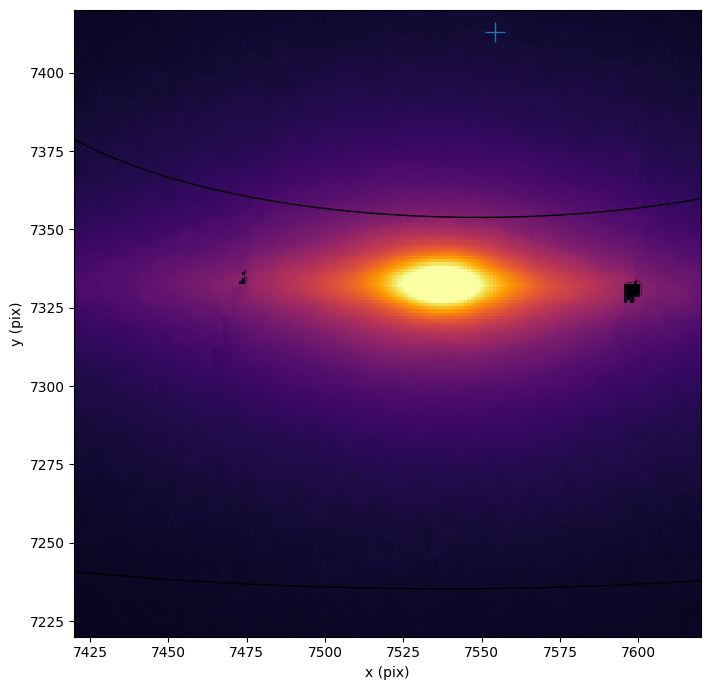

In [30]:
#zm_region = np.array([[7500, 8500], [7500, 8500]]) - 450
# Custom geometry overlay
xc, yc = res_g['x_cen'], res_g['y_cen']
pa = float(f.pa) #float(res_g['pa_rad'])#
eps = float(f.eps)
qbar = 1.0 - eps
pixel_scale=0.031


fig, ax = plt.subplots(figsize=(10, 7))
#ax.imshow(mg_help._stretch_for_display(img, goodmask=goodmask), origin="lower")
ax.imshow(img_for_find, origin="lower", cmap='inferno',
          vmin=np.percentile(img_for_find, 0.1), vmax=np.percentile(img_for_find, 99.9999)
        )
try:
    ax.contour((~goodmask).astype(float), levels=[0.5], linewidths=0.8, alpha=0.8, origin="lower")
except Exception:
    pass
ax.plot([xc], [yc], marker="+", markersize=14) # note that it is not inverted

L_arcsec = 20.0
L_pix = L_arcsec / pixel_scale
pa_rad = np.deg2rad(pa)
dx = L_pix * np.sin(pa_rad)
dy = L_pix * np.cos(pa_rad)
ax.plot([yc - dx, yc + dx], [xc - dy, xc + dy], linewidth=1.2)

for a_arc in [5.0, 15.0, 30.0]:
    a_pix = a_arc / pixel_scale
    b_pix = a_pix * qbar
    e = Ellipse((xc, yc), width=2*a_pix, height=2*b_pix, angle=(90.0 - pa),
                fill=False, linewidth=1.0)
    ax.add_patch(e)

#ax.set_title(f"{prefix}: geometry overlay  (PA={pa:.2f} deg, eps={eps:.3f})")
ax.set_xlabel("x (pix)")
ax.set_ylabel("y (pix)")
ax.set_xlim(zm_region[0][0], zm_region[0][1])
ax.set_ylim(zm_region[1][0], zm_region[1][1])
fig.tight_layout()
#fig.savefig(os.path.join(checkplot_dir, f"{prefix}_01_geometry_overlay.png"), dpi=dpi)
#plt.close(fig)
plt.show()